In [ ]:
,!pip install kaggle


In [ ]:
!kaggle datasets download bhavikjikadara/dog-and-cat-classification-dataset

Dataset URL: https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset
License(s): apache-2.0
100% 775M/775M [00:06<00:00, 133MB/s]



In [ ]:
!unzip  dog-and-cat-classification-dataset.zipb b. b

Streaming output truncated to the last 5000 lines.
  inflating: PetImages/Dog/5499.jpg  
  inflating: PetImages/Dog/55.jpg    
  inflating: PetImages/Dog/550.jpg   
  inflating: PetImages/Dog/5500.jpg  
  inflating: PetImages/Dog/5501.jpg  
  inflating: PetImages/Dog/5502.jpg  
  inflating: PetImages/Dog/5503.jpg  
  inflating: PetImages/Dog/5504.jpg  
  inflating: PetImages/Dog/5505.jpg  
  inflating: PetImages/Dog/5506.jpg  
  inflating: PetImages/Dog/5507.jpg  
  inflating: PetImages/Dog/5508.jpg  
  inflating: PetImages/Dog/5509.jpg  
  inflating: PetImages/Dog/551.jpg   
  inflating: PetImages/Dog/5510.jpg  
  inflating: PetImages/Dog/5511.jpg  
  inflating: PetImages/Dog/5512.jpg  
  inflating: PetImages/Dog/5513.jpg  
  inflating: PetImages/Dog/5514.jpg  
  inflating: PetImages/Dog/5515.jpg  
  inflating: PetImages/Dog/5516.jpg  
  inflating: PetImages/Dog/5517.jpg  
  inflating: PetImages/Dog/5518.jpg  
  inflating: PetImages/Dog/5519.jpg  
  inflating: PetImages/Dog/552.jpg   

In [ ]:
os.listdir('/content')

['.config',
 'PetImages',
 'dog-and-cat-classification-dataset.zip',
 'sample_data']

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets , transforms
import torch.optim as optim
from torch.utils.data import DataLoader ,random_split

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu' )
print(device)

cuda


In [ ]:
transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128,128)),
    transforms.ToTensor()

])

In [ ]:
dataset = datasets.ImageFolder(root= '/content/PetImages',
                               transform = transforms)
print(dataset.classes)

['Cat', 'Dog']


In [ ]:
train_size = int(0.8*len(dataset))
test_size = len(dataset)-train_size

train_dataset ,test_dataset = random_split(dataset,[train_size,test_size])

print(len(train_dataset))
print(len(test_dataset))

19998
5000


In [ ]:
train_loader = DataLoader(train_dataset ,batch_size = 32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size = 32 , shuffle = False)

In [ ]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(1,32,kernel_size=3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),


            nn.Conv2d(64,128,kernel_size = 3,padding =1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,kernel_size = 3,padding =1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)


        )

        self.fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(256*8*8,512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512,128),
            nn.ReLU(),
            nn.Dropout(0.3),


            nn.Linear(128,2)

        )

    def forward(self, x):

        x = self.conv(x)
        x = self.fc(x)

        return x

model = CNN().to(device)
print(model)

CNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14):

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 10
for epoch in range(epochs):
  model.train()
  total_loss = 0
  correct = 0
  total =0

  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    loss = criterion(outputs,labels)

    optimizer.zero_grad()
    loss.backward()

    optimizer.step()
    total_loss +=loss.item()
    _ ,predicted= torch.max(outputs ,1)
    correct+=(predicted ==labels).sum().item()

    total+=labels.size(0)

  accuracy = 100*correct / total
  print(f"Epoch {epoch+1}")
  print(f'Loss: {total_loss:.4f}')
  print(f'Accuracy: {accuracy:.2f}%')

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1
Loss: 431.9306
Accuracy: 59.49%
Epoch 2
Loss: 333.8294
Accuracy: 73.59%
Epoch 3
Loss: 280.0582
Accuracy: 79.98%
Epoch 4
Loss: 237.9929
Accuracy: 83.44%
Epoch 5
Loss: 203.2310
Accuracy: 86.36%
Epoch 6
Loss: 171.0797
Accuracy: 88.70%
Epoch 7
Loss: 148.6610
Accuracy: 90.35%
Epoch 8
Loss: 126.5204
Accuracy: 91.85%
Epoch 9
Loss: 114.1822
Accuracy: 92.55%
Epoch 10
Loss: 98.4042
Accuracy: 93.66%


In [ ]:
model.eval()

correct = 0
total =0

with torch.no_grad():
  for images ,labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    _,predicted = torch.max(outputs ,1)
    correct+=(predicted ==labels).sum().item()

    total+=labels.size(0)

accuracy = 100*correct / total
print(f'Accuracy: {accuracy:.2f}%')

Accuracy: 89.00%


In [ ]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt


In [ ]:
uploded  = files.upload()

Saving dog.avif to dog.avif


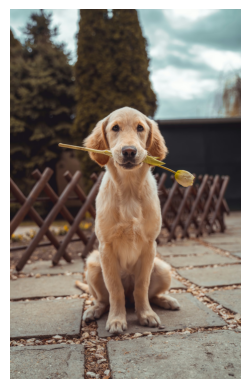

In [ ]:
img_path = list(uploded.keys())[0]
img = Image.open(img_path).convert('RGB')

plt.imshow(img)
plt.axis('off')
plt.show()


In [ ]:
import torch
from torchvision import transforms
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128,128)),
    transforms.ToTensor()
])


img_tensor = transform(img).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    output = model(img_tensor)
    pred = torch.argmax(output,1)

classes = ['Cat','Dog']

print("Prediction:", classes[pred.item()])

Prediction: Dog


In [1]:
!git config --global user.name "suxay"
!git config --global user.email "suchayj2508@gmail.com"

In [19]:
%cd /content



/content


In [20]:
!rm -rf .git
!rm -rf cat-dog-predict-pytorch/.git

In [21]:
!ls -a

.  ..  cat-dog-predict-pytorch	.config  sample_data


In [22]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [23]:
%%writefile .gitignore
.config/
sample_data/
PetImages/
*.zip
*.pth
*.pt
__pycache__/
.ipynb_checkpoints/

Writing .gitignore


In [24]:
!git config --global user.name "sucxay"
!git config --global user.email "suchayj2508@gmail.com"


In [25]:
!git add .

In [26]:
!git commit -m "Trained Model"

[master (root-commit) 6d507ca] Trained Model
 1 file changed, 8 insertions(+)
 create mode 100644 .gitignore


In [27]:
!git remote add origin https://github.com/sucxay/cat-dog-predict-pytorch.git

In [29]:
import getpass

token = getpass.getpass("GitHub Token: ")

GitHub Token: ··········


In [32]:
!zip -r all_files.zip /content

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/gce (stored 0%)
  adding: content/.config/configurations/ (stored 0%)
  adding: content/.config/configurations/config_default (deflated 15%)
  adding: content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: content/.config/.last_survey_prompt.yaml (stored 0%)
  adding: content/.config/active_config (stored 0%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2026.05.18/ (stored 0%)
  adding: content/.config/logs/2026.05.18/13.26.48.703307.log (deflated 57%)
  adding: content/.config/logs/2026.05.18/13.26.49.559528.log (deflated 56%)
  adding: content/.config/logs/2026.05.18/13.26.29.642900.log (deflated 87%)
  adding: content/.config/logs/2026.05.18/13.25.54.745593.log (deflated 92%)
  adding: content/.config/logs/2026.05.18/13.26.31.618620.log (deflated 58%)
  adding: content/.config/logs/2026.05.18/13.26.13.953937.lo

In [33]:
from google.colab import files
files.download("all_files.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>